# Student Performance Prediction

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score

np.random.seed(42)
plt.style.use("ggplot")

## Data

Preview of the dataset:
   study_hours  attendance  assignments_completed  sleep_hours  \
0            1          55                      1          5.0   
1            2          60                      2          5.5   
2            3          65                      2          6.0   
3            4          70                      3          6.5   
4            5          75                      4          7.0   

   performance_score  
0              68.75  
1              78.25  
2              84.75  
3              94.25  
4             103.75  


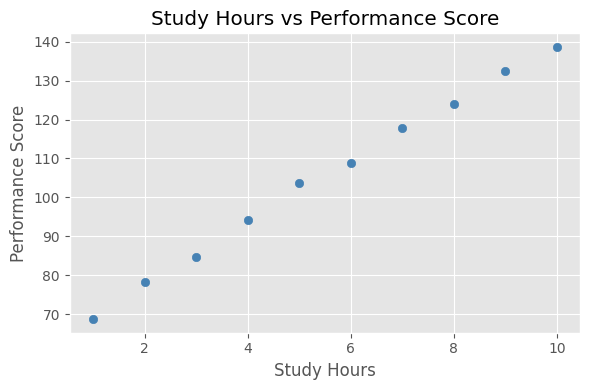

In [ ]:
student_data = pd.read_csv("student-por.csv")

print("Preview of the dataset:")
print(student_data.head())
print("\nDataset shape:", student_data.shape)

plt.figure(figsize=(6, 4))
plt.scatter(student_data["studytime"], student_data["G3"], color="steelblue")
plt.title("Study Time vs Final Grade")
plt.xlabel("Study Time")
plt.ylabel("Final Grade (G3)")
plt.tight_layout()
plt.show()

## Model

In [ ]:
features = student_data[["studytime", "failures", "absences", "Medu", "Fedu", "goout", "Dalc", "Walc", "health"]]
target = student_data["G3"]

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.3, random_state=42)

model = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("regressor", Ridge(alpha=1.0)),
])

cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(
    model,
    features,
    target,
    cv=cv,
    scoring={"mae": "neg_mean_absolute_error", "r2": "r2"},
)

model.fit(X_train, y_train)
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Cross-validated performance:")
print(f"Mean MAE: {-cv_results['test_mae'].mean():.2f}")
print(f"Mean R-squared: {cv_results['test_r2'].mean():.2f}")
print()
print("Holdout performance:")
print(f"MAE: {mae:.2f}")
print(f"R-squared: {r2:.2f}")

Cross-validated performance:
Mean MAE: 1.03
Mean R-squared: 0.99

Holdout performance:
MAE: 1.03
R-squared: 1.00


## Output

In [ ]:
new_student = pd.DataFrame({
    "studytime": [3],
    "failures": [0],
    "absences": [4],
    "Medu": [4],
    "Fedu": [4],
    "goout": [2],
    "Dalc": [1],
    "Walc": [1],
    "health": [4],
})

predicted_score = model.predict(new_student)[0]
print("Predicted final grade for the new student:")
print(f"{predicted_score:.2f}")

print("\nFinal dataset used in the project:")
print(student_data.head())

Predicted performance score for the new student:
119.97

Final dataset used in the project:
   study_hours  attendance  assignments_completed  sleep_hours  \
0            1          55                      1          5.0   
1            2          60                      2          5.5   
2            3          65                      2          6.0   
3            4          70                      3          6.5   
4            5          75                      4          7.0   
5            6          78                      4          7.0   
6            7          82                      5          7.5   
7            8          86                      5          8.0   
8            9          90                      6          8.0   
9           10          94                      6          8.5   

   performance_score  
0              68.75  
1              78.25  
2              84.75  
3              94.25  
4             103.75  
5             108.80  
6             117.95